# 问题二补充模型：FILT. NTU History-only Dynamic Inertia Model

本 notebook 是第二问的一个**单纯自历史项模型**，用于给建模手证明：

```text
滤后水浊度 FILT. NTU 本身具有动态惯性。
```

它不加入：

```text
R/W NTU
R/W PH
ALUM
F/RIDE
R/W FLOW
RIVER LEVEL
R/W CLR
PUMP COUNT
rolling features
interaction features
```

只加入：

```text
FILT. NTU_lag1
FILT. NTU_lag2
FILT. NTU_lag3
...
```

用于建立：

```text
FILT.NTU_t = f(FILT.NTU_{t-1}, FILT.NTU_{t-2}, ..., FILT.NTU_{t-k})
```

这个模型的作用不是替代第二题最终模型，而是作为一个**动态惯性证据模型**：

```text
如果只用 FILT. NTU 自身历史项就能取得不错的 R²，
说明滤后水浊度存在明显的自回归动态结构。
```

输出目录：

```text
outputs/problem2_history_only/
```


## 1. 导入依赖库

本 notebook 使用简单回归模型：

```text
Linear Regression
Ridge
ElasticNet
```

为了兼容旧版 scikit-learn，RMSE 使用：

```python
np.sqrt(mean_squared_error(y_true, y_pred))
```


In [1]:
from pathlib import Path
import warnings
import joblib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)

print("依赖库导入完成。")


依赖库导入完成。


## 2. 参数设置

目标变量：

```text
FILT. NTU
```

模型只使用 `FILT. NTU` 自身历史项。

候选滞后阶数：

```text
AR(1)：过去 2 小时
AR(3)：过去 2、4、6 小时
AR(6)：过去 2–12 小时
AR(12)：过去 2–24 小时
```

数据每 2 小时记录一次，因此：

```text
lag1 = 2 小时前
lag3 = 6 小时前
lag12 = 24 小时前
```


In [2]:
TARGET_COL = "FILT. NTU"
OUTPUT_DIR_NAME = "problem2_history_only"

RANDOM_STATE = 42

TRAIN_RATIO = 0.70
RECORD_INTERVAL_HOURS = 2

# 只测试自历史项，不加任何外生变量
AR_LAG_SETS = {
    "AR1": [1],
    "AR3": [1, 2, 3],
    "AR6": [1, 2, 3, 4, 5, 6],
    "AR12": list(range(1, 13)),
}

# 默认不 clipping，保持真实 FILT. NTU
CLIP_TARGET = False
TARGET_CLIP_UPPER = 2.0

print("参数设置完成。")


参数设置完成。


## 3. 自动定位 `merged.xlsx`

本 notebook 从原始 `merged.xlsx` 读取。  
不依赖第二题其他中间文件。


In [3]:
def locate_merged_file(filename="merged.xlsx"):
    cwd = Path.cwd().resolve()
    candidates = []

    search_roots = [cwd] + list(cwd.parents)

    for root in search_roots:
        candidates.extend([
            root / "data" / filename,
            root / "codes" / "data" / filename,
            root / "2026-Asia-Pacific-cup" / "data" / filename,
            root / "2026-Asia-Pasific-cup" / "data" / filename,
            root / filename,
        ])

    seen = set()
    unique_candidates = []

    for p in candidates:
        p = p.resolve()
        if p not in seen:
            seen.add(p)
            unique_candidates.append(p)

    for p in unique_candidates:
        if p.exists():
            return p

    for p in cwd.rglob(filename):
        return p.resolve()

    for parent in cwd.parents:
        try:
            for p in parent.rglob(filename):
                return p.resolve()
        except Exception:
            pass

    searched = "\n".join(str(p) for p in unique_candidates)
    raise FileNotFoundError(f"未找到 {filename}。已检查路径：\n{searched}")


DATA_PATH = locate_merged_file()
DATA_DIR = DATA_PATH.parent

if DATA_DIR.name == "data":
    PROJECT_DIR = DATA_DIR.parent
else:
    PROJECT_DIR = DATA_DIR

OUTPUT_DIR = PROJECT_DIR / "outputs" / OUTPUT_DIR_NAME
FIG_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("当前工作目录：", Path.cwd().resolve())
print("使用数据文件：", DATA_PATH)
print("输出目录：", OUTPUT_DIR)


当前工作目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\codes
使用数据文件： E:\桌面\亚太杯\2026-Asia-Pasific-cup\data\merged.xlsx
输出目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only


## 4. 读取数据并构造时间列

构造：

```text
DATETIME
OP_DATE
```

`OP_DATE` 使用前面题目一致的运行日定义：

```text
07:00 至次日 05:00 归为同一个运行日。
```


In [4]:
df = pd.read_excel(DATA_PATH)

print("原始数据规模：", df.shape)
print("原始列名：")
print(df.columns.tolist())

if TARGET_COL not in df.columns:
    raise ValueError(f"未找到目标变量 {TARGET_COL}。请检查 merged.xlsx。")


def construct_datetime(data):
    data = data.copy()

    if "DATETIME" in data.columns:
        data["DATETIME"] = pd.to_datetime(data["DATETIME"], errors="coerce")
        return data

    date_candidates = ["DATE", "Date", "date"]
    time_candidates = ["TIME", "Time", "time"]

    date_col = next((c for c in date_candidates if c in data.columns), None)
    time_col = next((c for c in time_candidates if c in data.columns), None)

    if date_col is None or time_col is None:
        raise ValueError("无法构造 DATETIME：需要 DATE 和 TIME 两列，或已有 DATETIME 列。")

    date_text = data[date_col].astype(str).str.split().str[0]
    time_text = data[time_col].astype(str).str.split().str[-1]

    data["DATETIME"] = pd.to_datetime(
        date_text + " " + time_text,
        errors="coerce",
    )

    return data


df = construct_datetime(df)
df = df.dropna(subset=["DATETIME"]).sort_values("DATETIME").reset_index(drop=True)

df["OP_DATE"] = df["DATETIME"].dt.date
mask_before_7 = df["DATETIME"].dt.hour < 7

df.loc[mask_before_7, "OP_DATE"] = (
    df.loc[mask_before_7, "DATETIME"] - pd.Timedelta(days=1)
).dt.date

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

if CLIP_TARGET:
    before_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    df[TARGET_COL] = df[TARGET_COL].clip(upper=TARGET_CLIP_UPPER)
    after_above = int((df[TARGET_COL] > TARGET_CLIP_UPPER).sum())
    print(f"{TARGET_COL} clipping: before_above={before_above}, after_above={after_above}")
else:
    print("未启用 FILT. NTU clipping。")

print("时间范围：", df["DATETIME"].min(), "至", df["DATETIME"].max())
print("\nFILT. NTU 描述统计：")
display(df[TARGET_COL].describe())

display(df[["DATETIME", "OP_DATE", TARGET_COL]].head(15))


原始数据规模： (5460, 18)
原始列名：
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW']
未启用 FILT. NTU clipping。
时间范围： 2025-01-01 07:00:00 至 2026-04-01 05:00:00

FILT. NTU 描述统计：


count    5460.000000
mean        0.190306
std         0.578003
min         0.020000
25%         0.040000
50%         0.060000
75%         0.110000
max         9.800000
Name: FILT. NTU, dtype: float64

,DATETIME,OP_DATE,FILT. NTU
0,2025-01-01 07:00:00,2025-01-01,0.04
1,2025-01-01 09:00:00,2025-01-01,0.05
2,2025-01-01 11:00:00,2025-01-01,0.05
3,2025-01-01 13:00:00,2025-01-01,0.05
4,2025-01-01 15:00:00,2025-01-01,0.05
5,2025-01-01 17:00:00,2025-01-01,0.06
6,2025-01-01 19:00:00,2025-01-01,0.05
7,2025-01-01 21:00:00,2025-01-01,0.05
8,2025-01-01 23:00:00,2025-01-01,0.05
9,2025-01-02 01:00:00,2025-01-01,0.05


## 5. 数据审计

只审计：

```text
DATETIME
OP_DATE
FILT. NTU
```

输出：

```text
problem2_history_only_data_audit.xlsx
```


In [5]:
base_df = df[["DATETIME", "OP_DATE", TARGET_COL]].copy()
base_df = base_df.dropna(subset=["DATETIME", TARGET_COL]).sort_values("DATETIME").reset_index(drop=True)

audit_df = pd.DataFrame({
    "column": ["DATETIME", "OP_DATE", TARGET_COL],
    "dtype": [str(base_df[c].dtype) for c in ["DATETIME", "OP_DATE", TARGET_COL]],
    "missing_count": [int(base_df[c].isna().sum()) for c in ["DATETIME", "OP_DATE", TARGET_COL]],
    "missing_rate": [float(base_df[c].isna().mean()) for c in ["DATETIME", "OP_DATE", TARGET_COL]],
    "unique_count": [int(base_df[c].nunique(dropna=True)) for c in ["DATETIME", "OP_DATE", TARGET_COL]],
})

audit_path = OUTPUT_DIR / "problem2_history_only_data_audit.xlsx"
audit_df.to_excel(audit_path, index=False)

print("基础数据规模：", base_df.shape)
print("数据审计已保存：", audit_path)
display(audit_df)


基础数据规模： (5460, 3)
数据审计已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_data_audit.xlsx


,column,dtype,missing_count,missing_rate,unique_count
0,DATETIME,datetime64[us],0,0.0,5460
1,OP_DATE,object,0,0.0,455
2,FILT. NTU,float64,0,0.0,210


## 6. 构造 `FILT. NTU` 自历史 lag 特征

只构造：

```text
FILT. NTU_lag1
FILT. NTU_lag2
...
FILT. NTU_lag12
```

不构造任何外生变量。

注意：

```text
不使用 FILT. NTU_lag0，因为 lag0 就是当前目标，会造成 target leakage。
```


In [6]:
feature_df = base_df.copy().sort_values("DATETIME").reset_index(drop=True)

max_lag = max(max(lags) for lags in AR_LAG_SETS.values())

lag_features = []

for lag in range(1, max_lag + 1):
    col_name = f"{TARGET_COL}_lag{lag}"
    feature_df[col_name] = feature_df[TARGET_COL].shift(lag)
    lag_features.append(col_name)

feature_summary_df = pd.DataFrame([
    {
        "feature": f"{TARGET_COL}_lag{lag}",
        "source_variable": TARGET_COL,
        "feature_type": "target_self_history_lag",
        "lag": lag,
        "lag_hours": lag * RECORD_INTERVAL_HOURS,
    }
    for lag in range(1, max_lag + 1)
])

feature_summary_path = OUTPUT_DIR / "problem2_history_only_feature_summary.xlsx"
feature_summary_df.to_excel(feature_summary_path, index=False)

print("已构造自历史特征数：", len(lag_features))
print("特征说明已保存：", feature_summary_path)
display(feature_summary_df)


已构造自历史特征数： 12
特征说明已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_feature_summary.xlsx


,feature,source_variable,feature_type,lag,lag_hours
0,FILT. NTU_lag1,FILT. NTU,target_self_history_lag,1,2
1,FILT. NTU_lag2,FILT. NTU,target_self_history_lag,2,4
2,FILT. NTU_lag3,FILT. NTU,target_self_history_lag,3,6
3,FILT. NTU_lag4,FILT. NTU,target_self_history_lag,4,8
4,FILT. NTU_lag5,FILT. NTU,target_self_history_lag,5,10
5,FILT. NTU_lag6,FILT. NTU,target_self_history_lag,6,12
6,FILT. NTU_lag7,FILT. NTU,target_self_history_lag,7,14
7,FILT. NTU_lag8,FILT. NTU,target_self_history_lag,8,16
8,FILT. NTU_lag9,FILT. NTU,target_self_history_lag,9,18
9,FILT. NTU_lag10,FILT. NTU,target_self_history_lag,10,20


## 7. 构造建模数据

目标：

```text
target_FILT_NTU = FILT. NTU_t
```

输入：

```text
不同 AR 阶数下的 FILT. NTU 历史项
```

例如：

```text
AR3 使用 FILT. NTU_lag1, FILT. NTU_lag2, FILT. NTU_lag3
```


In [7]:
model_data = feature_df[["DATETIME", "OP_DATE", TARGET_COL] + lag_features].copy()
model_data = model_data.rename(columns={TARGET_COL: "target_FILT_NTU"})

model_data = model_data.dropna(subset=["DATETIME", "target_FILT_NTU"]).sort_values("DATETIME").reset_index(drop=True)

model_data_path = OUTPUT_DIR / "problem2_history_only_model_data.xlsx"
model_data.to_excel(model_data_path, index=False)

print("建模数据规模：", model_data.shape)
print("建模数据已保存：", model_data_path)
display(model_data.head())


建模数据规模： (5460, 15)
建模数据已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_model_data.xlsx


,DATETIME,OP_DATE,target_FILT_NTU,FILT. NTU_lag1,FILT. NTU_lag2,FILT. NTU_lag3,FILT. NTU_lag4,FILT. NTU_lag5,FILT. NTU_lag6,FILT. NTU_lag7,FILT. NTU_lag8,FILT. NTU_lag9,FILT. NTU_lag10,FILT. NTU_lag11,FILT. NTU_lag12
0,2025-01-01 07:00:00,2025-01-01,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-01-01 09:00:00,2025-01-01,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2025-01-01 11:00:00,2025-01-01,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2025-01-01 13:00:00,2025-01-01,0.05,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2025-01-01 15:00:00,2025-01-01,0.05,0.05,0.05,0.05,0.04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 8. 时间顺序划分训练集和测试集

采用统一时间顺序划分：

```text
前 70% train
后 30% test
```

避免未来信息泄漏。


In [8]:
n = len(model_data)
split_idx = int(n * TRAIN_RATIO)

train_df = model_data.iloc[:split_idx].copy()
test_df = model_data.iloc[split_idx:].copy()

y_train = train_df["target_FILT_NTU"].values
y_test = test_df["target_FILT_NTU"].values

print("总样本数：", n)
print("训练集：", train_df.shape, train_df["DATETIME"].min(), "至", train_df["DATETIME"].max())
print("测试集：", test_df.shape, test_df["DATETIME"].min(), "至", test_df["DATETIME"].max())


总样本数： 5460
训练集： (3821, 15) 2025-01-01 07:00:00 至 2025-11-15 15:00:00
测试集： (1639, 15) 2025-11-15 17:00:00 至 2026-04-01 05:00:00


## 9. 定义模型和评价函数

模型包括：

```text
Linear Regression
Ridge
ElasticNet
```

这些模型适合用于解释自回归动态关系。


In [9]:
def evaluate_regression(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    mask = np.abs(y_true) > 1e-6
    if mask.sum() > 0:
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan

    return {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2,
        "MAPE_percent": mape,
    }


def build_models():
    models = {}

    models["Linear Regression"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LinearRegression()),
    ])

    models["Ridge"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ])

    models["ElasticNet"] = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.2, random_state=RANDOM_STATE, max_iter=20000)),
    ])

    return models


print("模型和评价函数定义完成。")


模型和评价函数定义完成。


## 10. 训练不同 AR 阶数的 history-only 模型

比较：

```text
AR1
AR3
AR6
AR12
```

每个 AR 阶数下训练：

```text
Linear Regression
Ridge
ElasticNet
```

输出：

```text
problem2_history_only_model_results.xlsx
problem2_history_only_test_predictions.xlsx
models/
```


In [10]:
results_records = []
prediction_frames = []
trained_models = {}

for ar_name, lags in AR_LAG_SETS.items():
    feature_cols = [f"{TARGET_COL}_lag{lag}" for lag in lags]

    print("=" * 80)
    print(f"Training {ar_name}: features = {feature_cols}")
    print("=" * 80)

    X_train = train_df[feature_cols].copy()
    X_test = test_df[feature_cols].copy()

    models = build_models()

    for model_name, model in models.items():
        print(f"Training {ar_name} - {model_name} ...")

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        metrics = evaluate_regression(y_test, y_pred)

        record = {
            "feature_set": ar_name,
            "model": model_name,
            "lags": ",".join(map(str, lags)),
            "lag_hours": ",".join(map(str, [lag * RECORD_INTERVAL_HOURS for lag in lags])),
            "n_features": len(feature_cols),
            "train_samples": len(X_train),
            "test_samples": len(X_test),
            **metrics,
        }

        results_records.append(record)

        pred_df = test_df[["DATETIME", "OP_DATE", "target_FILT_NTU"]].copy()
        pred_df["feature_set"] = ar_name
        pred_df["model"] = model_name
        pred_df["predicted_FILT_NTU"] = y_pred
        pred_df["residual"] = pred_df["target_FILT_NTU"] - pred_df["predicted_FILT_NTU"]
        prediction_frames.append(pred_df)

        key = f"{ar_name}__{model_name}"
        trained_models[key] = {
            "model": model,
            "features": feature_cols,
            "metrics": metrics,
        }

        model_path = MODEL_DIR / f"p2_history_only_{ar_name}_{model_name}.joblib".replace(" ", "_")
        joblib.dump({
            "model": model,
            "feature_cols": feature_cols,
            "target_col": "target_FILT_NTU",
            "feature_set": ar_name,
            "model_name": model_name,
            "metrics": metrics,
        }, model_path)

        print(f"  MAE={metrics['MAE']:.6f}, RMSE={metrics['RMSE']:.6f}, R2={metrics['R2']:.6f}")

results_df = pd.DataFrame(results_records).sort_values(["RMSE", "MAE"], ascending=[True, True]).reset_index(drop=True)
predictions_df = pd.concat(prediction_frames, ignore_index=True)

results_path = OUTPUT_DIR / "problem2_history_only_model_results.xlsx"
predictions_path = OUTPUT_DIR / "problem2_history_only_test_predictions.xlsx"

results_df.to_excel(results_path, index=False)
predictions_df.to_excel(predictions_path, index=False)

print("模型结果已保存：", results_path)
print("测试集预测已保存：", predictions_path)
display(results_df)


Training AR1: features = ['FILT. NTU_lag1']
Training AR1 - Linear Regression ...
  MAE=0.056826, RMSE=0.250859, R2=0.560761
Training AR1 - Ridge ...
  MAE=0.056848, RMSE=0.250839, R2=0.560832
Training AR1 - ElasticNet ...
  MAE=0.057788, RMSE=0.250015, R2=0.563714
Training AR3: features = ['FILT. NTU_lag1', 'FILT. NTU_lag2', 'FILT. NTU_lag3']
Training AR3 - Linear Regression ...
  MAE=0.057278, RMSE=0.246471, R2=0.575995
Training AR3 - Ridge ...
  MAE=0.057278, RMSE=0.246469, R2=0.575999
Training AR3 - ElasticNet ...
  MAE=0.057720, RMSE=0.247884, R2=0.571117
Training AR6: features = ['FILT. NTU_lag1', 'FILT. NTU_lag2', 'FILT. NTU_lag3', 'FILT. NTU_lag4', 'FILT. NTU_lag5', 'FILT. NTU_lag6']
Training AR6 - Linear Regression ...
  MAE=0.057565, RMSE=0.245206, R2=0.580335
Training AR6 - Ridge ...
  MAE=0.057566, RMSE=0.245192, R2=0.580382
Training AR6 - ElasticNet ...
  MAE=0.057479, RMSE=0.245758, R2=0.578444
Training AR12: features = ['FILT. NTU_lag1', 'FILT. NTU_lag2', 'FILT. NTU_lag3'

,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12,Ridge,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.058291,0.244140,0.583975,38.829285
1,AR12,Linear Regression,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.058297,0.244151,0.583939,38.815986
2,AR12,ElasticNet,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.056925,0.244973,0.581132,37.597184
3,AR6,Ridge,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.057566,0.245192,0.580382,37.354203
4,AR6,Linear Regression,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.057565,0.245206,0.580335,37.330490
5,AR6,ElasticNet,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.057479,0.245758,0.578444,38.410783
6,AR3,Ridge,"1,2,3","2,4,6",3,3821,1639,0.057278,0.246469,0.575999,37.427952
7,AR3,Linear Regression,"1,2,3","2,4,6",3,3821,1639,0.057278,0.246471,0.575995,37.402534
8,AR3,ElasticNet,"1,2,3","2,4,6",3,3821,1639,0.057720,0.247884,0.571117,38.695209
9,AR1,ElasticNet,1,2,1,3821,1639,0.057788,0.250015,0.563714,38.885699


## 11. 提取线性模型系数

系数用于解释：

```text
FILT. NTU_lag1
FILT. NTU_lag2
...
```

对当前 `FILT. NTU` 的影响强度和方向。

输出：

```text
problem2_history_only_coefficients.xlsx
```


In [11]:
coef_records = []

for key, item in trained_models.items():
    ar_name, model_name = key.split("__", 1)

    if model_name not in ["Linear Regression", "Ridge", "ElasticNet"]:
        continue

    model = item["model"]
    feature_cols = item["features"]

    estimator = model.named_steps["model"]

    if not hasattr(estimator, "coef_"):
        continue

    coef_df = pd.DataFrame({
        "feature_set": ar_name,
        "model": model_name,
        "feature": feature_cols,
        "coefficient": estimator.coef_,
    })

    coef_df["abs_coefficient"] = coef_df["coefficient"].abs()
    coef_df = coef_df.sort_values("abs_coefficient", ascending=False)

    coef_records.append(coef_df)

coef_df = pd.concat(coef_records, ignore_index=True) if coef_records else pd.DataFrame()

coef_path = OUTPUT_DIR / "problem2_history_only_coefficients.xlsx"
coef_df.to_excel(coef_path, index=False)

print("系数表已保存：", coef_path)
display(coef_df.head(50))


系数表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_coefficients.xlsx


,feature_set,model,feature,coefficient,abs_coefficient
0,AR1,Linear Regression,FILT. NTU_lag1,0.588714,0.588714
1,AR1,Ridge,FILT. NTU_lag1,0.588559,0.588559
2,AR1,ElasticNet,FILT. NTU_lag1,0.582057,0.582057
3,AR3,Linear Regression,FILT. NTU_lag1,0.643663,0.643663
4,AR3,Linear Regression,FILT. NTU_lag2,-0.131786,0.131786
5,AR3,Linear Regression,FILT. NTU_lag3,0.079699,0.079699
6,AR3,Ridge,FILT. NTU_lag1,0.642417,0.642417
7,AR3,Ridge,FILT. NTU_lag2,-0.130231,0.130231
8,AR3,Ridge,FILT. NTU_lag3,0.079281,0.079281
9,AR3,ElasticNet,FILT. NTU_lag1,0.586753,0.586753


## 12. 与外生 selected-lag baseline 对比

如果存在：

```text
outputs/problem2_arx_residual_hybrid/problem2_arx_residual_model_results.xlsx
```

则自动读取其中的 `SelectedLag` baseline 和 `ARX` 结果，方便比较：

```text
仅外生变量 selected-lag
vs
仅 FILT. NTU 自历史项
vs
ARX
```


In [12]:
comparison_frames = []

history_compare = results_df.copy()
history_compare["version"] = "FILT_NTU_history_only"
history_compare["model_group"] = "HistoryOnly"
comparison_frames.append(history_compare)

arx_residual_path = PROJECT_DIR / "outputs" / "problem2_arx_residual_hybrid" / "problem2_arx_residual_model_results.xlsx"

if arx_residual_path.exists():
    arx_compare = pd.read_excel(arx_residual_path)
    arx_compare["version"] = "ARX_residual_notebook"
    comparison_frames.append(arx_compare)
    print("已读取 ARX residual notebook 结果：", arx_residual_path)
else:
    print("未找到 ARX residual notebook 结果，跳过对比。")

common_cols = [
    "version",
    "model_group",
    "feature_set",
    "model",
    "n_features",
    "MAE",
    "RMSE",
    "R2",
    "MAPE_percent",
]

comparison_df = pd.concat(
    [df_.reindex(columns=common_cols) for df_ in comparison_frames],
    ignore_index=True,
)

comparison_df = comparison_df.sort_values("RMSE", ascending=True).reset_index(drop=True)

comparison_path = OUTPUT_DIR / "problem2_history_only_comparison_with_arx.xlsx"
comparison_df.to_excel(comparison_path, index=False)

print("对比表已保存：", comparison_path)
display(comparison_df)


已读取 ARX residual notebook 结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_arx_residual_hybrid\problem2_arx_residual_model_results.xlsx
对比表已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_comparison_with_arx.xlsx


,version,model_group,feature_set,model,n_features,MAE,RMSE,R2,MAPE_percent
0,FILT_NTU_history_only,HistoryOnly,AR12,Ridge,12,0.058291,0.244140,0.583975,38.829285
1,FILT_NTU_history_only,HistoryOnly,AR12,Linear Regression,12,0.058297,0.244151,0.583939,38.815986
2,FILT_NTU_history_only,HistoryOnly,AR12,ElasticNet,12,0.056925,0.244973,0.581132,37.597184
3,FILT_NTU_history_only,HistoryOnly,AR6,Ridge,6,0.057566,0.245192,0.580382,37.354203
4,FILT_NTU_history_only,HistoryOnly,AR6,Linear Regression,6,0.057565,0.245206,0.580335,37.330490
5,FILT_NTU_history_only,HistoryOnly,AR6,ElasticNet,6,0.057479,0.245758,0.578444,38.410783
6,FILT_NTU_history_only,HistoryOnly,AR3,Ridge,3,0.057278,0.246469,0.575999,37.427952
7,FILT_NTU_history_only,HistoryOnly,AR3,Linear Regression,3,0.057278,0.246471,0.575995,37.402534
8,FILT_NTU_history_only,HistoryOnly,AR3,ElasticNet,3,0.057720,0.247884,0.571117,38.695209
9,ARX_residual_notebook,Direct,ARX,Ridge,8,0.069896,0.248029,0.570617,61.586224


## 13. 可视化：不同 AR 阶数模型性能

输出：

```text
figures/problem2_history_only_rmse_comparison.png
figures/problem2_history_only_r2_comparison.png
```


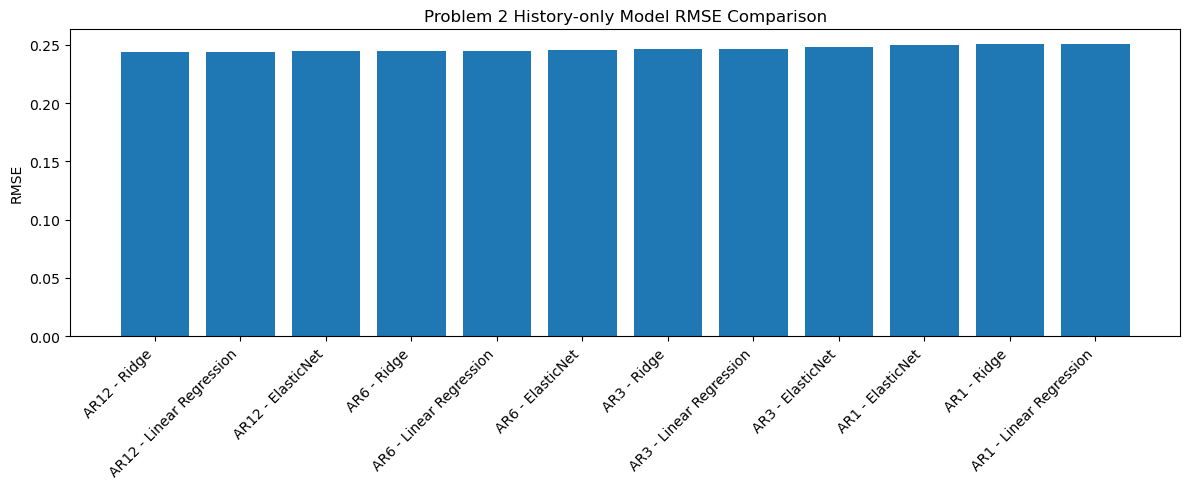

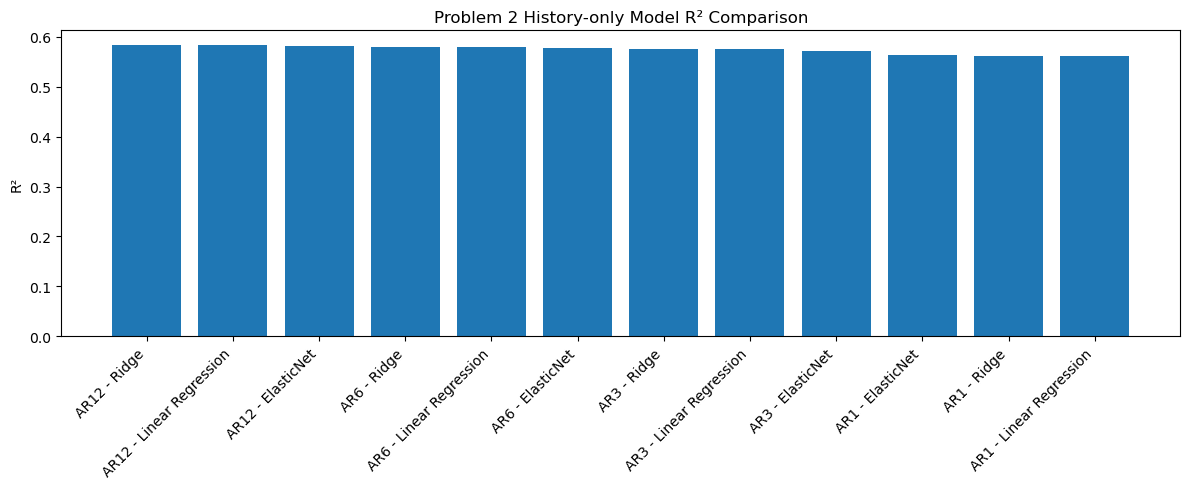

RMSE 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\figures\problem2_history_only_rmse_comparison.png
R² 图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\figures\problem2_history_only_r2_comparison.png


In [13]:
plot_df = results_df.copy()
plot_df["label"] = plot_df["feature_set"] + " - " + plot_df["model"]

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["RMSE"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("RMSE")
plt.title("Problem 2 History-only Model RMSE Comparison")
plt.tight_layout()

rmse_fig_path = FIG_DIR / "problem2_history_only_rmse_comparison.png"
plt.savefig(rmse_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(plot_df["label"], plot_df["R2"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("R²")
plt.title("Problem 2 History-only Model R² Comparison")
plt.tight_layout()

r2_fig_path = FIG_DIR / "problem2_history_only_r2_comparison.png"
plt.savefig(r2_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("RMSE 图已保存：", rmse_fig_path)
print("R² 图已保存：", r2_fig_path)


## 14. 可视化：最佳模型预测曲线和残差图

根据 RMSE 最小原则选择最佳 history-only 模型。


最佳 history-only 模型：


,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12,Ridge,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.058291,0.24414,0.583975,38.829285


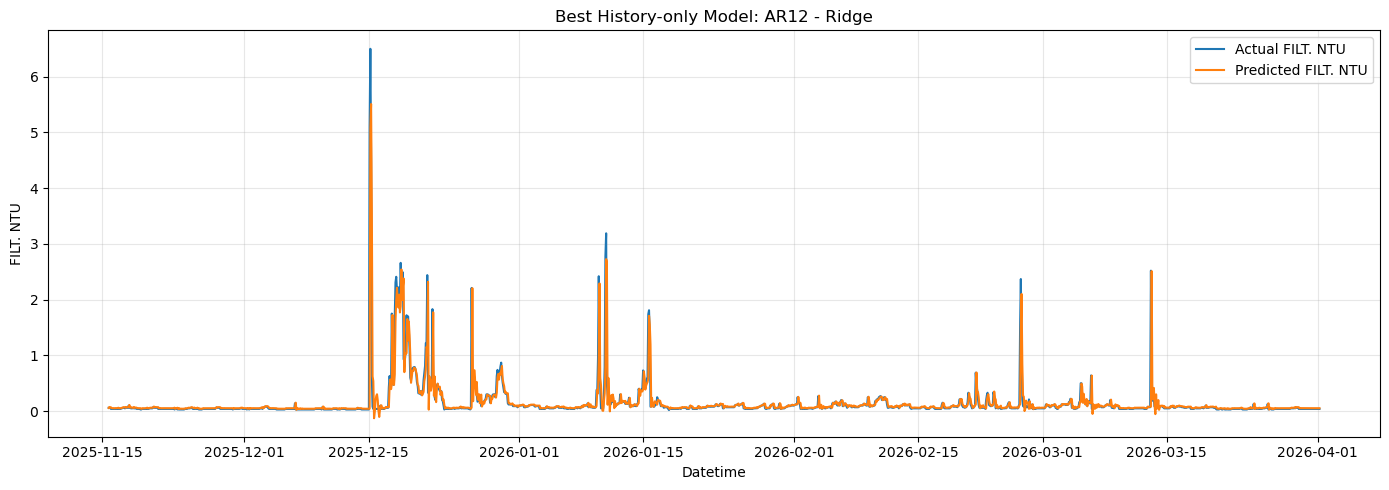

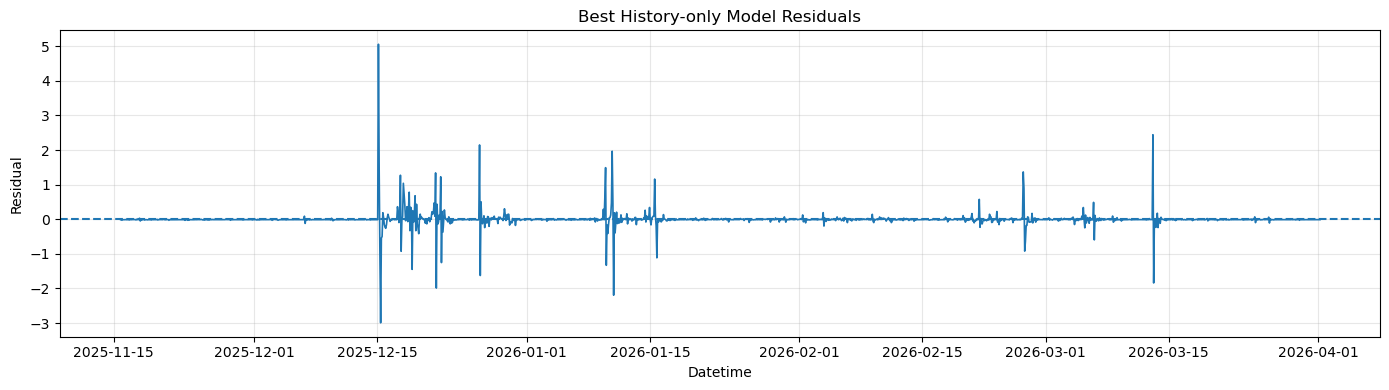

最佳模型预测图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\figures\problem2_history_only_best_model_timeseries.png
残差图已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\figures\problem2_history_only_best_model_residuals.png


In [14]:
best_row = results_df.iloc[0]
best_feature_set = best_row["feature_set"]
best_model_name = best_row["model"]

best_pred_df = predictions_df[
    (predictions_df["feature_set"] == best_feature_set) &
    (predictions_df["model"] == best_model_name)
].copy()

print("最佳 history-only 模型：")
display(best_row.to_frame().T)

plt.figure(figsize=(14, 5))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["target_FILT_NTU"],
    label="Actual FILT. NTU",
    linewidth=1.5,
)
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["predicted_FILT_NTU"],
    label="Predicted FILT. NTU",
    linewidth=1.5,
)
plt.title(f"Best History-only Model: {best_feature_set} - {best_model_name}")
plt.xlabel("Datetime")
plt.ylabel("FILT. NTU")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

best_ts_fig_path = FIG_DIR / "problem2_history_only_best_model_timeseries.png"
plt.savefig(best_ts_fig_path, dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(14, 4))
plt.plot(
    best_pred_df["DATETIME"],
    best_pred_df["residual"],
    linewidth=1.2,
)
plt.axhline(0, linestyle="--")
plt.title("Best History-only Model Residuals")
plt.xlabel("Datetime")
plt.ylabel("Residual")
plt.grid(alpha=0.3)
plt.tight_layout()

residual_fig_path = FIG_DIR / "problem2_history_only_best_model_residuals.png"
plt.savefig(residual_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("最佳模型预测图已保存：", best_ts_fig_path)
print("残差图已保存：", residual_fig_path)


## 15. 输出最终摘要

输出：

```text
problem2_history_only_final_summary.xlsx
```

这个表可以直接给建模手使用。


In [15]:
final_summary = pd.DataFrame([
    {
        "item": "model_family",
        "value": "FILT. NTU History-only Dynamic Inertia Model",
    },
    {
        "item": "target",
        "value": "FILT. NTU",
    },
    {
        "item": "input_variables",
        "value": "Only FILT. NTU historical lags. No exogenous variables are used.",
    },
    {
        "item": "best_feature_set",
        "value": best_feature_set,
    },
    {
        "item": "best_model",
        "value": best_model_name,
    },
    {
        "item": "best_MAE",
        "value": best_row["MAE"],
    },
    {
        "item": "best_RMSE",
        "value": best_row["RMSE"],
    },
    {
        "item": "best_R2",
        "value": best_row["R2"],
    },
    {
        "item": "interpretation",
        "value": "If R² is high, the filtered water turbidity has strong dynamic inertia driven by its own previous states.",
    },
])

final_summary_path = OUTPUT_DIR / "problem2_history_only_final_summary.xlsx"
final_summary.to_excel(final_summary_path, index=False)

print("最终摘要已保存：", final_summary_path)
display(final_summary)


最终摘要已保存： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_final_summary.xlsx


,item,value
0,model_family,FILT. NTU History-only Dynamic Inertia Model
1,target,FILT. NTU
2,input_variables,Only FILT. NTU historical lags. No exogenous v...
3,best_feature_set,AR12
4,best_model,Ridge
5,best_MAE,0.058291
6,best_RMSE,0.24414
7,best_R2,0.583975
8,interpretation,"If R² is high, the filtered water turbidity ha..."


## 16. 论文中可以使用的表述

可以写：

```text
为检验滤后水浊度 FILT. NTU 是否具有显著动态惯性，本文进一步构建仅包含 FILT. NTU 自身历史项的 history-only 自回归模型。该模型不引入任何原水水质、投药量或流量变量，仅使用 FILT. NTU_lag1 至 FILT. NTU_lagk 预测当前 FILT. NTU。若该模型在测试集上取得较高 R²，则说明滤后水浊度的短期变化主要受自身历史状态影响，系统存在明显动态惯性。
```

英文：

```text
To examine whether filtered water turbidity exhibits significant dynamic inertia, a history-only autoregressive model was constructed using only lagged FILT. NTU terms. No raw-water, chemical dosing, or flow variables were included. If this model achieves a relatively high test R², it indicates that the short-term variation of FILT. NTU is strongly governed by its previous states, implying strong dynamic persistence in the filtration process.
```


In [16]:
print("=" * 80)
print("问题二 FILT. NTU history-only 动态惯性模型已完成。")
print("=" * 80)

print("\n核心输出文件：")
print("1. 数据审计：", audit_path)
print("2. 特征说明：", feature_summary_path)
print("3. 建模数据：", model_data_path)
print("4. 模型结果：", results_path)
print("5. 测试集预测：", predictions_path)
print("6. 系数表：", coef_path)
print("7. 与 ARX 对比表：", comparison_path)
print("8. 最终摘要：", final_summary_path)
print("9. 图片目录：", FIG_DIR)
print("10. 模型目录：", MODEL_DIR)

print("\n模型结果：")
display(results_df)

print("\n最佳 history-only 模型：")
display(best_row.to_frame().T)

print("\n最终摘要：")
display(final_summary)


问题二 FILT. NTU history-only 动态惯性模型已完成。

核心输出文件：
1. 数据审计： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_data_audit.xlsx
2. 特征说明： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_feature_summary.xlsx
3. 建模数据： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_model_data.xlsx
4. 模型结果： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_model_results.xlsx
5. 测试集预测： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_test_predictions.xlsx
6. 系数表： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_coefficients.xlsx
7. 与 ARX 对比表： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_comparison_with_arx.xlsx
8. 最终摘要： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs\problem2_history_only\problem2_history_only_final_summary.xlsx
9. 图片目录： E:\桌面\亚太杯\2026-Asia-Pasific-cup\outputs

,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12,Ridge,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.058291,0.244140,0.583975,38.829285
1,AR12,Linear Regression,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.058297,0.244151,0.583939,38.815986
2,AR12,ElasticNet,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.056925,0.244973,0.581132,37.597184
3,AR6,Ridge,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.057566,0.245192,0.580382,37.354203
4,AR6,Linear Regression,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.057565,0.245206,0.580335,37.330490
5,AR6,ElasticNet,"1,2,3,4,5,6","2,4,6,8,10,12",6,3821,1639,0.057479,0.245758,0.578444,38.410783
6,AR3,Ridge,"1,2,3","2,4,6",3,3821,1639,0.057278,0.246469,0.575999,37.427952
7,AR3,Linear Regression,"1,2,3","2,4,6",3,3821,1639,0.057278,0.246471,0.575995,37.402534
8,AR3,ElasticNet,"1,2,3","2,4,6",3,3821,1639,0.057720,0.247884,0.571117,38.695209
9,AR1,ElasticNet,1,2,1,3821,1639,0.057788,0.250015,0.563714,38.885699



最佳 history-only 模型：


,feature_set,model,lags,lag_hours,n_features,train_samples,test_samples,MAE,RMSE,R2,MAPE_percent
0,AR12,Ridge,"1,2,3,4,5,6,7,8,9,10,11,12","2,4,6,8,10,12,14,16,18,20,22,24",12,3821,1639,0.058291,0.24414,0.583975,38.829285



最终摘要：


,item,value
0,model_family,FILT. NTU History-only Dynamic Inertia Model
1,target,FILT. NTU
2,input_variables,Only FILT. NTU historical lags. No exogenous v...
3,best_feature_set,AR12
4,best_model,Ridge
5,best_MAE,0.058291
6,best_RMSE,0.24414
7,best_R2,0.583975
8,interpretation,"If R² is high, the filtered water turbidity ha..."
